In [1]:
import os
import shutil
from pathlib import Path

bids_dir = Path("bids")

if os.path.exists(bids_dir):
    shutil.rmtree(bids_dir)

shutil.copytree("bids_demo", bids_dir)

PosixPath('bids')

# Process data

In [2]:
!tree {bids_dir}

bids
├── masks
│   └── leftHemisphere.nii.gz
├── metadata.tsv
└── subjects
    ├── sub-OAS30010
    │   └── ses-M000
    │       └── t1_linear
    │           ├── sub-OAS30010_ses-M000_space-MNI152NLin2009cSym_desc-Crop_res-1x1x1_T1w.nii.gz
    │           └── sub-OAS30010_ses-M000_space-MNI152NLin2009cSym_desc-Crop_res-1x1x1_label-head_mask.nii.gz
    ├── sub-OAS30011
    │   ├── ses-M000
    │   │   └── t1_linear
    │   │       ├── sub-OAS30011_ses-M000_space-MNI152NLin2009cSym_desc-Crop_res-1x1x1_T1w.nii.gz
    │   │       └── sub-OAS30011_ses-M000_space-MNI152NLin2009cSym_desc-Crop_res-1x1x1_label-head_mask.nii.gz
    │   └── ses-M054
    │       └── t1_linear
    │           ├── sub-OAS30011_ses-M054_space-MNI152NLin2009cSym_desc-Crop_res-1x1x1_T1w.nii.gz
    │           └── sub-OAS30011_ses-M054_space-MNI152NLin2009cSym_desc-Crop_res-1x1x1_label-head_mask.nii.gz
    ├── sub-OAS30012
    │   ├── ses-M006
    │   │   └── t1_linear
    │   │       ├── sub-OAS30012_ses-M006_space-MN

In [3]:
import torchio.transforms as transforms

from clinicadl.data.datasets import BidsLikeDataset
from clinicadl.data.datatypes import DataType
from clinicadl.transforms.extraction import Patch
from clinicadl.transforms.handlers import TransformsHandler

patch_dataset = BidsLikeDataset(
    directory=bids_dir,
    datatype=DataType(pattern="t1_linear/sub-.*_ses-.*_T1w.nii.gz", key="t1_linear"),
    data=bids_dir / "metadata.tsv",
    transforms=TransformsHandler(
        extraction=Patch(patch_size=16, overlap=0.8),
        image_transforms=[transforms.RescaleIntensity()],
        augmentations=[
            transforms.RandomFlip(),
            transforms.RandomElasticDeformation(),
            transforms.RandomMotion(),
            transforms.RandomGhosting(),
            transforms.RandomGamma(),
            transforms.RandomBiasField(),
            transforms.RandomBlur(),
        ],
    ),
    masks=["label-head_mask"],
)

full_image_dataset = BidsLikeDataset(
    directory=bids_dir,
    datatype=DataType(pattern="t1_linear/sub-.*_ses-.*_T1w.nii.gz", key="t1_linear"),
    data=bids_dir / "metadata.tsv",
    transforms=TransformsHandler(
        image_transforms=[transforms.RescaleIntensity()],
    ),
    masks=["label-head_mask"],
)

/Users/thibault.devarax/miniforge3/envs/clinicadl_dev/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/Users/thibault.devarax/miniforge3/envs/clinicadl_dev/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
full_image_dataset.to_tensors()
patch_dataset.read_tensor_conversion()

15:48:13 - Converting images and potential image-specific masks: 100%|██████████| 9/9 [00:00<00:00, 48.11it/s]
15:48:13 - Converting common masks: 0it [00:00, ?it/s]


In [5]:
patch_dataset.df

,participant_id,session_id,diagnosis,age,sex,n_samples
0,sub-OAS30010,ses-M000,CN,68,F,6
1,sub-OAS30011,ses-M000,CN,78,F,6
2,sub-OAS30011,ses-M054,CN,83,F,6
3,sub-OAS30012,ses-M006,CN,87,M,6
4,sub-OAS30012,ses-M018,CN,88,M,6
5,sub-OAS30013,ses-M006,AD,71,M,6
6,sub-OAS30014,ses-M006,CN,70,F,6
7,sub-OAS30014,ses-M036,CN,73,F,6
8,sub-OAS30015,ses-M000,AD,71,M,6


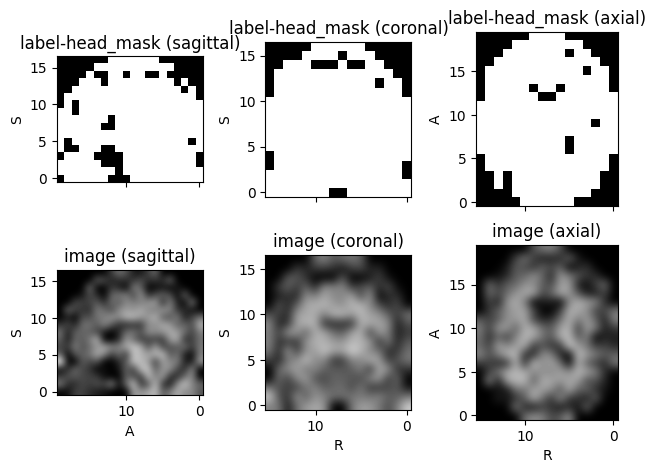

In [6]:
full_image_dataset[2].plot()

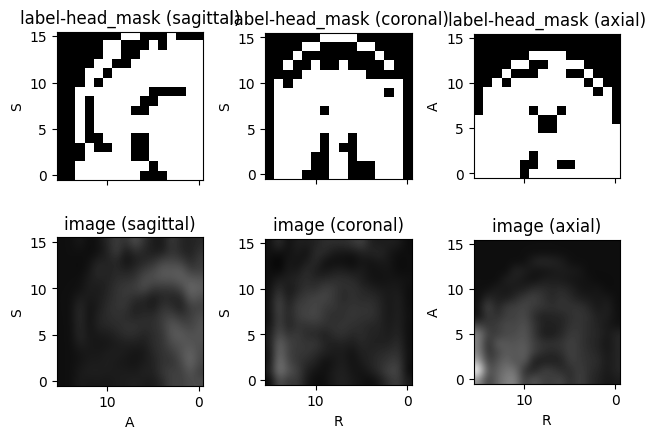

In [7]:
patch_dataset[10].plot()

In [8]:
from clinicadl.split import make_kfold, make_split

split_dir = make_split(bids_dir / "metadata.tsv", n_test=2, output_dir=bids_dir, stratification=["age", "sex"])

kfold_dir = make_kfold(split_dir / "train.tsv", n_splits=4, longitudinal=True)

# Train and evaluate a model

In [9]:
from monai.losses import DiceLoss

from clinicadl.infer import PatchesToImageInferer
from clinicadl.models import SupervisedModel
from clinicadl.networks.nn import UNet
from clinicadl.optim.optimizers.config import AdamConfig
from clinicadl.transforms.config import ActivationsConfig, AsDiscreteConfig

batch_size = 8

model = SupervisedModel(
    network=UNet(spatial_dims=3, in_channels=1, out_channels=1, channels=(4, 8)),
    loss=DiceLoss(sigmoid=True),
    optimizer=AdamConfig(),
    label="label-head_mask",
    inferer=PatchesToImageInferer(
        patch_size=16,
        overlap=0.5,
        batch_size=batch_size,
        output_name="seg",
        output_type="mask",
        postprocessing=[
            ActivationsConfig(sigmoid=True, include=["seg"]),
            AsDiscreteConfig(threshold=0.5, include=["seg"]),
        ],
    ),
)

In [10]:
from clinicadl.callbacks import (
    EarlyStoppingCallback,
    LRSchedulerCallback,
    ModelCheckpointCallback,
)
from clinicadl.metrics.config import LossMetricConfig, SurfaceDiceMetricConfig
from clinicadl.optim import OptimizationConfig
from clinicadl.optim.lr_schedulers.config import ExponentialLRConfig
from clinicadl.train import Trainer

maps_dir = Path("maps_demo")
num_epochs = 100

trainer = Trainer(
    maps=maps_dir,
    model=model,
    metrics={
        "surface dice": SurfaceDiceMetricConfig(
            class_thresholds=[1],
            pred_key="seg",
            label_key="label-head_mask",
        ),
        "loss": LossMetricConfig(
            loss_name="loss", pred_key="seg", label_key="label-head_mask"
        ),
    },
    optimization=OptimizationConfig(
        num_epochs=num_epochs,
        clip_grad_norm=1,
    ),
    callbacks=[
        EarlyStoppingCallback(metric="loss", patience=10, min_delta=0.01),
        LRSchedulerCallback(
            scheduler=ExponentialLRConfig(
                gamma=0.95,
            )
        ),
        ModelCheckpointCallback(metric="loss"),
    ],
    overwrite=True,
)

In [11]:
from clinicadl.split import KFold
from clinicadl.train import ComputationalConfig

kfold = KFold(kfold_dir)

for split in kfold.get_splits(
    patch_dataset, eval_dataset=full_image_dataset, splits=[0]
):
    split.build_train_loader(batch_size=batch_size, shuffle=True, drop_last=False)
    split.build_val_loader()

    trainer.train(
        split,
        computational=ComputationalConfig(
            gpu=False, amp=True, channels_last=True, deterministic=True, seed=1
        ),
    )

2026-03-09 15:48:15 - INFO: Beginning of training on split 0
2026-03-09 15:48:15 - INFO: Computational configuration: gpu=False non_blocking=True amp=True channels_last=True seed=1 deterministic=True
2026-03-09 15:48:15 - INFO: Beginning of epoch 1
Epoch 1/100: 100%|██████████| 3/3 [00:00<00:00,  2.57batch/s, loss=0.453]
2026-03-09 15:48:16 - INFO: Beginning of validation
Validation: 100%|██████████| 2/2 [00:00<00:00,  6.60batch/s]
2026-03-09 15:48:16 - INFO: End of validation
2026-03-09 15:48:16 - INFO: Epoch 1 completed
2026-03-09 15:48:16 - INFO: Beginning of epoch 2
Epoch 2/100: 100%|██████████| 3/3 [00:00<00:00,  2.75batch/s, loss=0.424]
2026-03-09 15:48:17 - INFO: Beginning of validation
Validation: 100%|██████████| 2/2 [00:00<00:00,  6.77batch/s]
2026-03-09 15:48:17 - INFO: End of validation
2026-03-09 15:48:17 - INFO: Epoch 2 completed
2026-03-09 15:48:17 - INFO: Beginning of epoch 3
Epoch 3/100: 100%|██████████| 3/3 [00:00<00:00,  2.76batch/s, loss=0.415]
2026-03-09 15:48:18 -

In [12]:
from clinicadl.data.dataloader import DataLoaderConfig

test_dataset = full_image_dataset.subset(split_dir / "test_baseline.tsv")
test_loader = DataLoaderConfig().get_object(test_dataset)

trainer.test(
    model_checkpoint="split-0_best-loss",
    dataloader=test_loader,
    group_name="oasis",
    computational=ComputationalConfig(gpu=False),
)

2026-03-09 15:48:34 - INFO: Beginning of test
Test: 100%|██████████| 2/2 [00:00<00:00,  6.08batch/s]
2026-03-09 15:48:34 - INFO: End of test
2026-03-09 15:48:34 - INFO: Test metrics saved in /Users/thibault.devarax/Desktop/code/clinicadl/maps_demo/test/group-oasis/results/split-0/best-loss


# Explore the results in your MAPS directory

In [13]:
from clinicadl.io import Maps

maps = Maps(maps_dir)
maps.read()

<Axes: xlabel='batch', ylabel='training loss'>

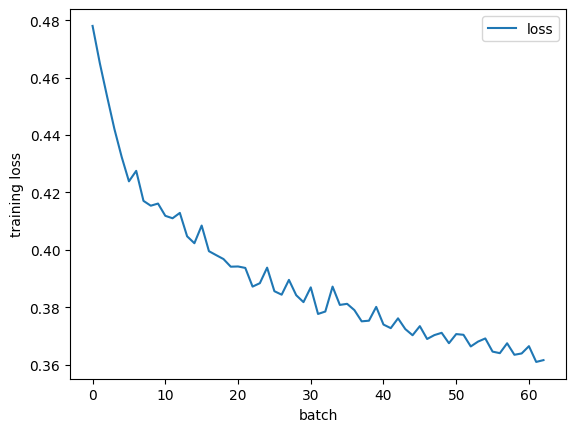

In [14]:
import matplotlib.pyplot as plt

ax = plt.subplot()
loss = maps.open_file(maps.training.splits[0].logs.training_loss_tsv)
loss.plot(xlabel="batch", ylabel="training loss", ax=ax)

<Axes: xlabel='epoch', ylabel='validation metrics'>

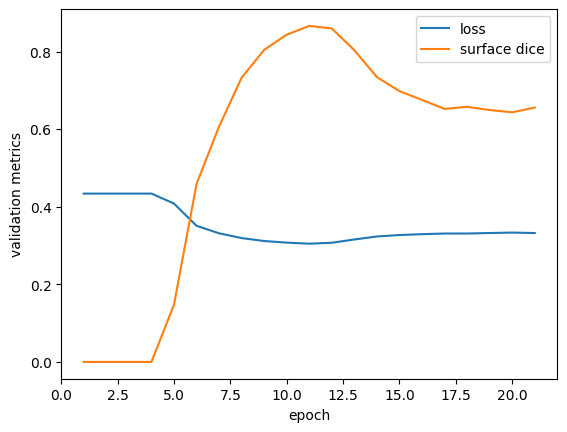

In [15]:
metrics = maps.open_file(maps.training.splits[0].validation_metrics.aggregated_tsv)
metrics.plot(y=["loss", "surface dice"], x="epoch", ylabel="validation metrics")

<Axes: title={'center': 'Learning Rate Schedule'}, xlabel='optimization step'>

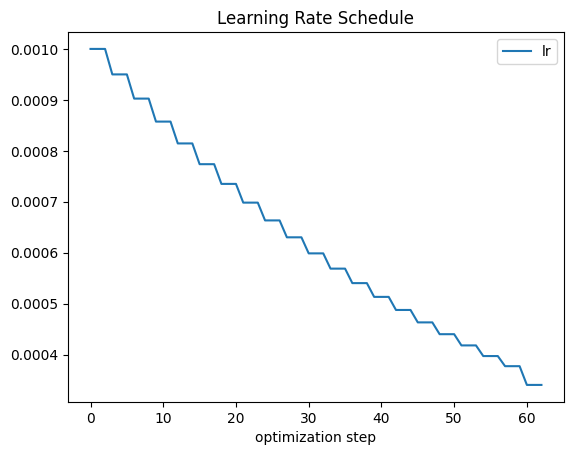

In [16]:
lrs = maps.open_file(maps.training.splits[0].logs.learning_rates / "optimizer.tsv")
lrs["optimization step"] = range(len(lrs))
lrs.plot(y="lr", x="optimization step", title="Learning Rate Schedule")

Text(0.5, 1.0, 'computation times during the training loop')

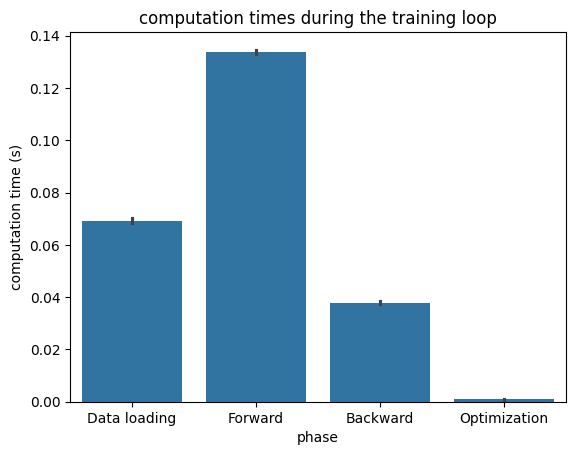

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

ax = plt.subplot()

computational_stats = maps.open_file(maps.training.splits[0].logs.computational_tsv)
training_loop = computational_stats[["Training data loading (s)", "Forward (s)", "Backward (s)", "Optimization (s)"]]
training_loop = training_loop.stack().reset_index(1).reset_index(drop=True)
training_loop.columns = ["phase", "computation time (s)"]
training_loop["phase"] = training_loop["phase"].apply(lambda x: x.replace(" (s)", "").replace("Training d", "D"))

sns.barplot(training_loop, y="computation time (s)", x="phase", ax=ax)
ax.set_title("computation times during the training loop")